10. Social Network data analysis  for community detection and influential analytics for given problem using Girvan newman algorithm / Kmean clustering algorithm

In [11]:
import pandas as pd
import networkx as nx
from networkx.algorithms import community
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('CSV/tweets.csv')
df.head()

,created_at,tweet,user,user_location,retweet_count,additional_data
0,05-02-2023 11:37,"Anyone who Belongs To The Society,\nWhoever Wi...",PVRTWEETSSS,NaN,0,{'created_at': 'Sun Feb 05 11:37:50 +0000 2023...
1,05-02-2023 10:51,"#NewProfilePic\nKeep Grinding, for the loved o...",Immortalayush_,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 10:51:44 +0000 2023...
2,05-02-2023 10:03,And people call him bad?\n#tate #FreeTheTates ...,hsenshamass,NaN,0,{'created_at': 'Sun Feb 05 10:03:48 +0000 2023...
3,05-02-2023 08:34,How's this poetry or you can call this poem. #...,kshitiz_999,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 08:34:39 +0000 2023...
4,05-02-2023 08:19,Andrew Tate’s Best Piece of advice…\n\nUnleash...,TheWolfCeo,NaN,0,{'created_at': 'Sun Feb 05 08:19:04 +0000 2023...


In [ ]:
df = df[df.user_location.notnull()][:10]
df['hashtags'] = ''

In [54]:
for i, row in df.iterrows():
    hashtags = [token for token in row.tweet.split() if token.startswith('#')]
    df['hashtags'][i] = hashtags
df.head()

C:\Users\Om Shete\AppData\Local\Temp\ipykernel_23856\2771581564.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['hashtags'][i] = hashtags
C:\Users\Om Shete\AppData\Local\Temp\ipykernel_23856\2771581564.py:3: SettingWithCopyWarning: 
A

,created_at,tweet,user,user_location,retweet_count,additional_data,hashtags,user_label
1,05-02-2023 10:51,"#NewProfilePic\nKeep Grinding, for the loved o...",Immortalayush_,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 10:51:44 +0000 2023...,#NewProfilePic,0
1,05-02-2023 10:51,"#NewProfilePic\nKeep Grinding, for the loved o...",Immortalayush_,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 10:51:44 +0000 2023...,#AndrewTate,0
1,05-02-2023 10:51,"#NewProfilePic\nKeep Grinding, for the loved o...",Immortalayush_,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 10:51:44 +0000 2023...,#khabib,0
1,05-02-2023 10:51,"#NewProfilePic\nKeep Grinding, for the loved o...",Immortalayush_,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 10:51:44 +0000 2023...,#ConorMcGregor,0
1,05-02-2023 10:51,"#NewProfilePic\nKeep Grinding, for the loved o...",Immortalayush_,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 10:51:44 +0000 2023...,#AskSRK,0


In [55]:
df = df.explode('hashtags')
users = list(df['user'].unique())
hashtags = list(df['hashtags'].unique())

In [56]:
# create graph
vis = nx.Graph()
vis.add_nodes_from(users + hashtags)

for name, group in df.groupby(['hashtags', 'user']):
    hashtag, user = name
    weight = len(group)
    vis.add_edge(hashtag, user, weight=weight)

In [57]:
community_gen = community.girvan_newman(vis)
print(community_gen)
top_level_communities = next(community_gen)

<generator object girvan_newman at 0x00000182A031B680>


In [58]:
communities = list(next(community_gen))
print(communities)

[{'Immortalayush_', '#STG', '#independent', '#Independent', '#AndrewTate', '#khabib', '#NewProfilePic', 'iamronbrooks', '#andrewtate', '#andrewtatemotivation', '#woodpilewisdom.', '#ConorMcGregor', '#woods', 'after_shook', '#AskSRK', '#adrewtatebusiness'}, {'#English', '#tate', '#FreeTopG', 'kshitiz_999', '#like4like', '#tatebrothers', '#andrewtaterelaese', '#Motivation', '#comments', '#TristanTate', '#MotivationalQuotes', 'SARSALI99', '#Lifegoeson'}, {'#theworldneedstoknowwhoyouare', '#truth', '#coverup', '#USA', 'idilaberentur', '#trials', '#Jeffery', '#loveisland', '#secrets', '#tellthetruth', '#lies'}]


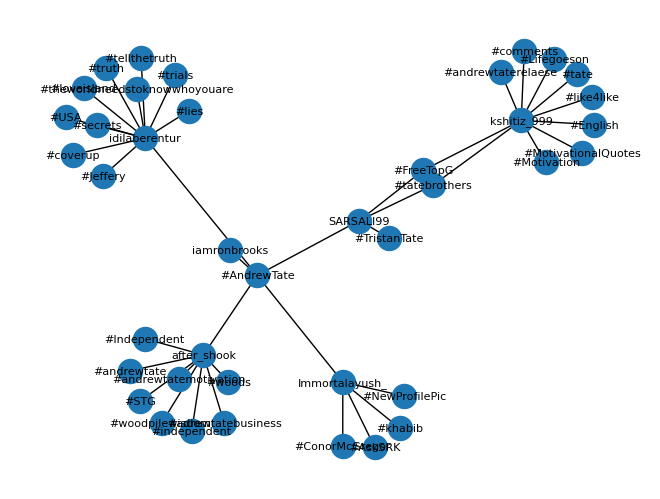

In [59]:
nx.draw(vis, with_labels=True, font_size=8)
plt.axis('off')
plt.show()

In [60]:
centrality = nx.betweenness_centrality(vis)
print(centrality)

{'Immortalayush_': 0.1970310391363023, 'kshitiz_999': 0.3731443994601889, 'after_shook': 0.3724696356275303, 'SARSALI99': 0.45276653171390013, 'iamronbrooks': 0.0, 'idilaberentur': 0.45209176788124156, '#NewProfilePic': 0.0, '#AndrewTate': 0.7584345479082321, '#khabib': 0.0, '#ConorMcGregor': 0.0, '#AskSRK': 0.0, '#Lifegoeson': 0.0, '#Motivation': 0.0, '#MotivationalQuotes': 0.0, '#andrewtaterelaese': 0.0, '#tate': 0.0, '#FreeTopG': 0.17611336032388664, '#tatebrothers': 0.17611336032388664, '#English': 0.0, '#like4like': 0.0, '#comments': 0.0, '#woodpilewisdom.': 0.0, '#STG': 0.0, '#woods': 0.0, '#independent': 0.0, '#andrewtatemotivation': 0.0, '#adrewtatebusiness': 0.0, '#andrewtate': 0.0, '#Independent': 0.0, '#TristanTate': 0.0, '#Jeffery': 0.0, '#theworldneedstoknowwhoyouare': 0.0, '#tellthetruth': 0.0, '#loveisland': 0.0, '#trials': 0.0, '#USA': 0.0, '#coverup': 0.0, '#secrets': 0.0, '#lies': 0.0, '#truth': 0.0}


In [61]:
print('Top 5 Most Influential Users/Hashtags based on betweenness centrality :- ')
influencial_nodes = sorted(
    centrality.items(), key= lambda item : item[1], reverse=True
)[:5]
print(centrality.items())

Top 5 Most Influential Users/Hashtags based on betweenness centrality :- 
dict_items([('Immortalayush_', 0.1970310391363023), ('kshitiz_999', 0.3731443994601889), ('after_shook', 0.3724696356275303), ('SARSALI99', 0.45276653171390013), ('iamronbrooks', 0.0), ('idilaberentur', 0.45209176788124156), ('#NewProfilePic', 0.0), ('#AndrewTate', 0.7584345479082321), ('#khabib', 0.0), ('#ConorMcGregor', 0.0), ('#AskSRK', 0.0), ('#Lifegoeson', 0.0), ('#Motivation', 0.0), ('#MotivationalQuotes', 0.0), ('#andrewtaterelaese', 0.0), ('#tate', 0.0), ('#FreeTopG', 0.17611336032388664), ('#tatebrothers', 0.17611336032388664), ('#English', 0.0), ('#like4like', 0.0), ('#comments', 0.0), ('#woodpilewisdom.', 0.0), ('#STG', 0.0), ('#woods', 0.0), ('#independent', 0.0), ('#andrewtatemotivation', 0.0), ('#adrewtatebusiness', 0.0), ('#andrewtate', 0.0), ('#Independent', 0.0), ('#TristanTate', 0.0), ('#Jeffery', 0.0), ('#theworldneedstoknowwhoyouare', 0.0), ('#tellthetruth', 0.0), ('#loveisland', 0.0), ('#tria

In [62]:
for node in influencial_nodes:
    print(f"{node[0]}: {node[1]}")

#AndrewTate: 0.7584345479082321
SARSALI99: 0.45276653171390013
idilaberentur: 0.45209176788124156
kshitiz_999: 0.3731443994601889
after_shook: 0.3724696356275303


In [63]:
label_encoder = LabelEncoder()

In [64]:
df['user_label'] = label_encoder.fit_transform(df['user'])
df['hashtag_label'] = label_encoder.fit_transform(df['hashtags'])
df.head()

,created_at,tweet,user,user_location,retweet_count,additional_data,hashtags,user_label,hashtag_label
1,05-02-2023 10:51,"#NewProfilePic\nKeep Grinding, for the loved o...",Immortalayush_,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 10:51:44 +0000 2023...,#NewProfilePic,0,10
1,05-02-2023 10:51,"#NewProfilePic\nKeep Grinding, for the loved o...",Immortalayush_,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 10:51:44 +0000 2023...,#AndrewTate,0,0
1,05-02-2023 10:51,"#NewProfilePic\nKeep Grinding, for the loved o...",Immortalayush_,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 10:51:44 +0000 2023...,#khabib,0,21
1,05-02-2023 10:51,"#NewProfilePic\nKeep Grinding, for the loved o...",Immortalayush_,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 10:51:44 +0000 2023...,#ConorMcGregor,0,2
1,05-02-2023 10:51,"#NewProfilePic\nKeep Grinding, for the loved o...",Immortalayush_,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 10:51:44 +0000 2023...,#AskSRK,0,1


In [65]:
X = df[['user_label' , 'hashtag_label']]
X.head()

,user_label,hashtag_label
1,0,10
1,0,0
1,0,21
1,0,2
1,0,1


In [66]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
df['cluster'] = kmeans.labels_
df.head()

,created_at,tweet,user,user_location,retweet_count,additional_data,hashtags,user_label,hashtag_label,cluster
1,05-02-2023 10:51,"#NewProfilePic\nKeep Grinding, for the loved o...",Immortalayush_,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 10:51:44 +0000 2023...,#NewProfilePic,0,10,2
1,05-02-2023 10:51,"#NewProfilePic\nKeep Grinding, for the loved o...",Immortalayush_,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 10:51:44 +0000 2023...,#AndrewTate,0,0,1
1,05-02-2023 10:51,"#NewProfilePic\nKeep Grinding, for the loved o...",Immortalayush_,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 10:51:44 +0000 2023...,#khabib,0,21,2
1,05-02-2023 10:51,"#NewProfilePic\nKeep Grinding, for the loved o...",Immortalayush_,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 10:51:44 +0000 2023...,#ConorMcGregor,0,2,1
1,05-02-2023 10:51,"#NewProfilePic\nKeep Grinding, for the loved o...",Immortalayush_,Place(_api=<tweepy.api.API object at 0x000001B...,0,{'created_at': 'Sun Feb 05 10:51:44 +0000 2023...,#AskSRK,0,1,1


Hashtags Labels


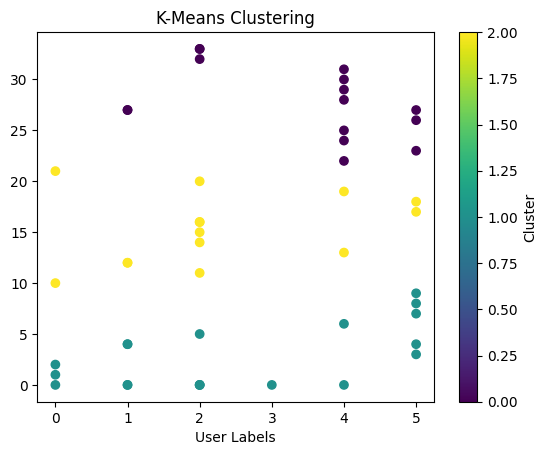

In [67]:
plt.scatter(df['user_label'], df['hashtag_label'], c=df['cluster'], cmap='viridis')
plt.xlabel('User Labels')
print('Hashtags Labels')
plt.title('K-Means Clustering')
plt.colorbar(label='Cluster')
plt.show()